# sachsray demo: generate → trace → angular power spectrum

End-to-end demonstration of the full-sky Sachs ray-tracer:

1. **Generate** a correlated full-sky driving field (Ricci focusing Φ₀₀ and Weyl shear Ψ₀) with a chosen angular power spectrum and line-of-sight correlation.
2. **Trace** every pixel as an independent ray through the linear Jacobi system and read off the weak-lensing observables (convergence κ, shear γ, rotation ω).
3. **Measure** the convergence angular power spectrum `C_ℓ^κ` and validate it against the analytic Born (weak-lensing) prediction.

> This demo uses a *synthetic* input spectrum (no cosmology dependency). For a real cosmology, generate the spectra and background with `perFLRW` (requires `pyccl`) and feed them in the same way. The driving field here is Gaussian, but the solver integrates whatever realisation it is handed — **non-Gaussian fields work identically**.

In [1]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import jax
jax.config.update("jax_enable_x64", True)  # demo accuracy; production uses float32

import sachsfield as sf       # field generation (per-mode Cholesky on the sphere)
import sachsray as sr         # the ray-tracer

# --- configuration ---
nside    = 64                 # healpix resolution -> npix = 12*nside^2 = 49152
lmax     = 3 * nside - 1
npix     = hp.nside2npix(nside)
lam0, lam_s = 0.1, 2.0        # affine-parameter range (observer-side -> source)
n_lam    = 128                # samples along the line of sight
A        = 5e-3               # input amplitude
print(f"nside={nside}  npix={npix}  lmax={lmax}  n_lam={n_lam}")

nside=64  npix=49152  lmax=191  n_lam=128


## 1. Generate the driving field

We build a Gaussian random field for each of the three driving channels — `(Φ₀₀, Ψ₊, Ψₓ)` — with a power-law angular spectrum `C_ℓ = A/[ℓ(ℓ+1)]` and a Gaussian line-of-sight correlation `ρ(Δλ) = exp[-½(Δλ/0.3)²]`. `FullSkySource` does this with a per-ℓ Cholesky factorisation so the field is correlated both across the sky and along λ.

In [2]:
lam = np.linspace(lam0, lam_s, n_lam)
ell = np.arange(lmax + 1)

def cl_func(lam_value):
    cl = np.zeros(lmax + 1)
    cl[2:] = A / (ell[2:] * (ell[2:] + 1.0))
    return cl, cl.copy(), cl.copy()   # (C_l^Phi00, C_l^Psi+, C_l^Psix)

source = sf.FullSkySource(
    cl_func=cl_func, lam_samples=lam, nside=nside,
    corr_func=lambda d: np.exp(-0.5 * (d / 0.3) ** 2), seed=1, n_fields=3,
)
source.generate()
print("generated fluctuation maps:", source._delta_s.shape, "= (channel, n_lam, npix)")

generated fluctuation maps: (3, 128, 49152) = (channel, n_lam, npix)


## 2. Bridge to a `DrivingField` and trace the rays

`driving_from_source` assembles the per-ray driving array `Φ₀₀ = Φ̄₀₀ + δΦ₀₀` (here the background `Φ̄₀₀ = 0`, i.e. a vacuum background `D̄ = λ`). `trace_rays` then integrates every pixel as an independent ray (`vmap`, chunked) and returns the lensing observable maps.

In [3]:
field = sr.driving_from_source(source, phi00_bg=np.zeros(n_lam), dtype=np.float64)

t0 = time.perf_counter()
obs = sr.trace_rays(field, lam_s, chunk=4096, rtol=1e-9, atol=1e-11)
print(f"traced {npix} rays in {time.perf_counter() - t0:.2f} s")

kappa  = np.asarray(obs["kappa"])
gamma1 = np.asarray(obs["gamma1"])
gamma2 = np.asarray(obs["gamma2"])
gamma  = np.hypot(gamma1, gamma2)
print(f"kappa : mean={kappa.mean():+.2e}  std={kappa.std():.3e}")
print(f"|gamma|: mean={gamma.mean():+.2e}  std={gamma.std():.3e}")

traced 49152 rays in 13.77 s
kappa : mean=-3.23e-04  std=2.506e-02
|gamma|: mean=+2.97e-02  std=1.563e-02


## 3. Visualise the convergence and shear maps

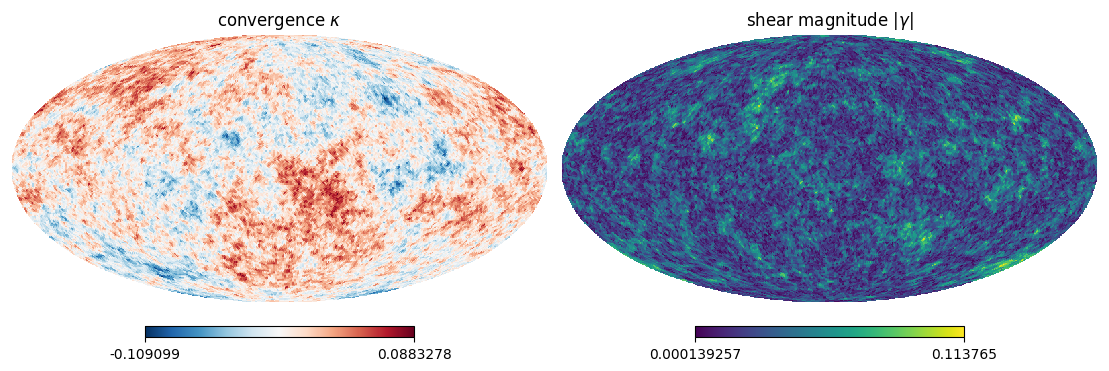

In [4]:
fig = plt.figure(figsize=(11, 4.5))
hp.mollview(kappa, title=r"convergence $\kappa$", sub=(1, 2, 1), cmap="RdBu_r", fig=fig.number)
hp.mollview(gamma, title=r"shear magnitude $|\gamma|$", sub=(1, 2, 2), cmap="viridis", fig=fig.number)
plt.show()

## 4. Angular power spectrum + Born validation

We estimate `C_ℓ^κ` from the convergence map with `healpy.anafast`, and compare to the analytic **Born** prediction

$$\kappa_{\rm Born}(\hat n) = -\int_{\lambda_0}^{\lambda_s} \frac{(\lambda_s-\lambda')(\lambda'-\lambda_0)}{\lambda_s-\lambda_0}\,\delta\Phi_{00}(\lambda',\hat n)\,d\lambda',$$

the standard lensing-efficiency line-of-sight integral of the focusing fluctuation (kernel vertex at `λ₀`, matching the ray-tracer's initial condition). The two spectra should agree in the weak regime.

C_l^kappa / C_l^Born  (10 <= l <= 128) = 1.0010
map cross-correlation  kappa vs kappa_Born   = 0.9999


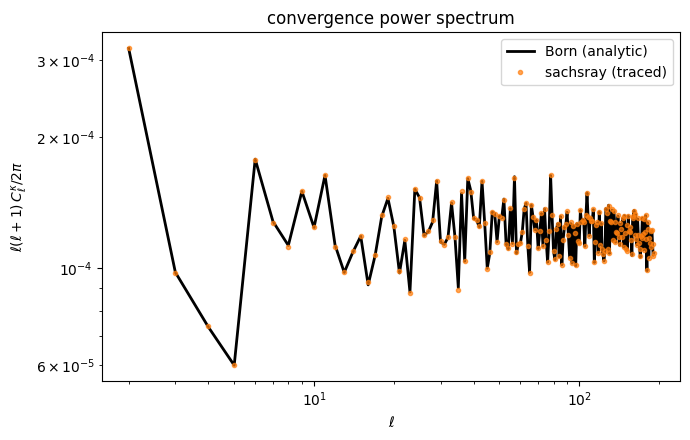

In [5]:
# measured convergence spectrum
cl_kappa = hp.anafast(kappa, lmax=lmax)

# analytic Born convergence map + spectrum (same realisation)
dphi = np.asarray(source._delta_s[0])                       # (n_lam, npix) = delta Phi00
kernel = (lam_s - lam) * (lam - lam0) / (lam_s - lam0)       # vertex at lam0
kappa_born = -np.trapezoid(kernel[:, None] * dphi, lam, axis=0)
cl_born = hp.anafast(kappa_born, lmax=lmax)

band = (ell >= 10) & (ell <= 2 * nside)
ratio = np.mean(cl_kappa[band] / cl_born[band])
xcorr = np.corrcoef(kappa, kappa_born)[0, 1]
print(f"C_l^kappa / C_l^Born  (10 <= l <= {2*nside}) = {ratio:.4f}")
print(f"map cross-correlation  kappa vs kappa_Born   = {xcorr:.4f}")

norm = ell * (ell + 1) / (2 * np.pi)
plt.figure(figsize=(7, 4.5))
plt.loglog(ell[2:], (norm * cl_born)[2:], "k-", lw=2, label="Born (analytic)")
plt.loglog(ell[2:], (norm * cl_kappa)[2:], "C1o", ms=3, alpha=0.7, label="sachsray (traced)")
plt.xlabel(r"$\ell$"); plt.ylabel(r"$\ell(\ell+1)\,C_\ell^{\kappa}/2\pi$")
plt.title(r"convergence power spectrum"); plt.legend(); plt.tight_layout(); plt.show()

## Notes

- **Validation.** `C_ℓ^κ` matches the analytic Born prediction to sub-percent, and the maps cross-correlate at ~1.0 — the full nonlinear ray-tracer reproduces the weak-lensing limit. Increase `A` to push beyond Born and expose the nonlinear FF propagation that the brute-force solve captures (and Born does not).
- **Real cosmology.** Replace `cl_func` with `perFLRW.FLRWCosmology(...).cl_func(...)` and pass `phi00_bg = cosmo.background_phi00_of_lambda(lam)` (requires `pyccl`).
- **Non-Gaussian inputs.** Feed any realisation via `sr.driving_from_components(ts, dPhi00, dPsi+, dPsix, phi00_bg)` — the solver integrates it directly; no drift/diffusion reduction needed.
- **Scale / memory.** For nside ≥ 256, use `sr.trace_rays_streaming(ts, lam_s, npix, gen_chunk, phi00_bg)` to generate each ray-block on the fly (peak memory ~ one chunk). See `prototype/scale_test.py`.
- **GPU.** The solver is device-agnostic; run unchanged on an NVIDIA/CUDA box for large maps.